TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64
21
0
   TransactionAmount Tran

C:\Users\galih\AppData\Local\Temp\ipykernel_13212\3772400231.py:107: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(df.select_dtypes(include=['object']).columns)


Silhouette Score: 0.49616537802441746


C:\Users\galih\AppData\Local\Temp\ipykernel_13212\3772400231.py:238: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
c:\Users\galih\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


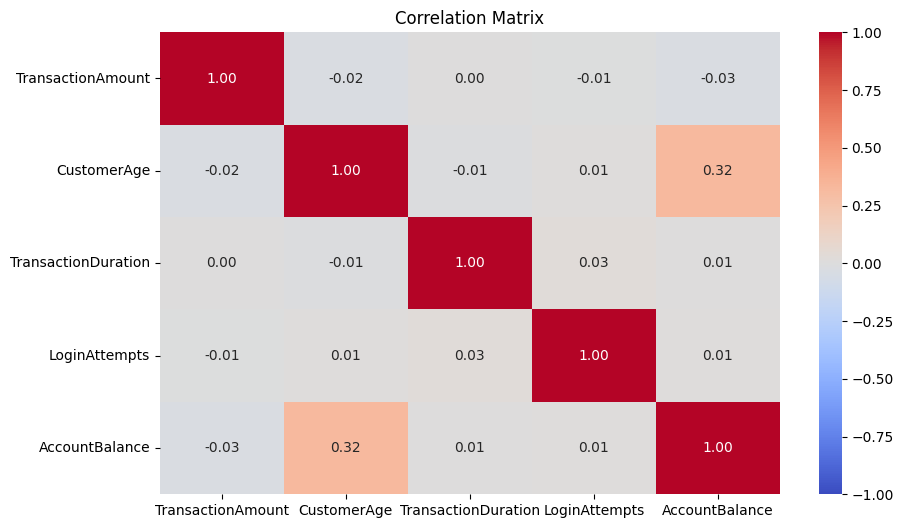

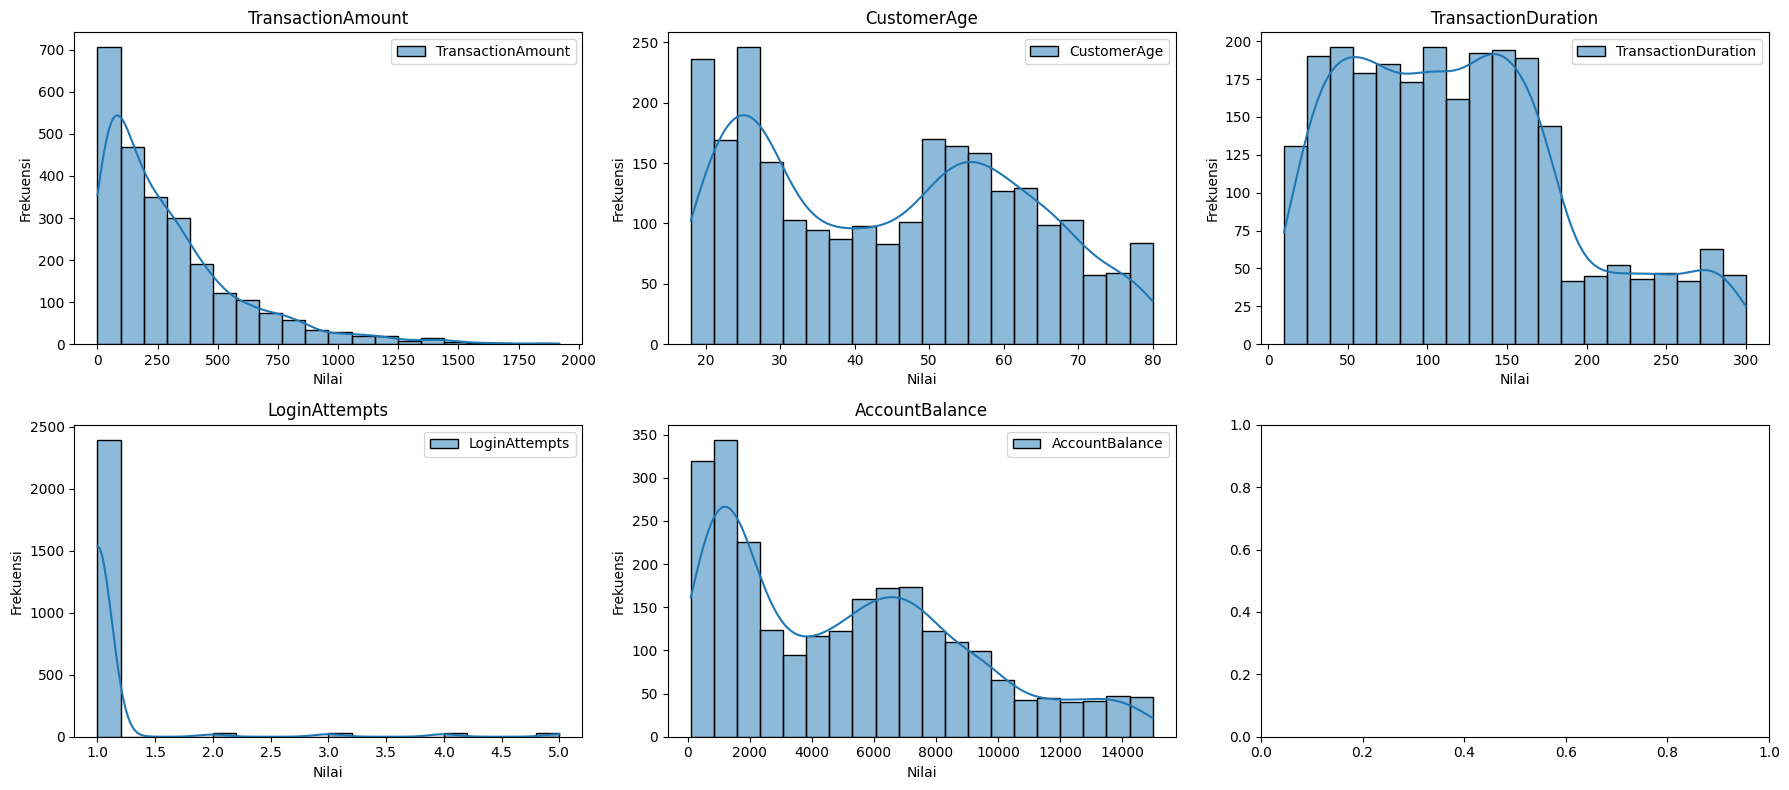

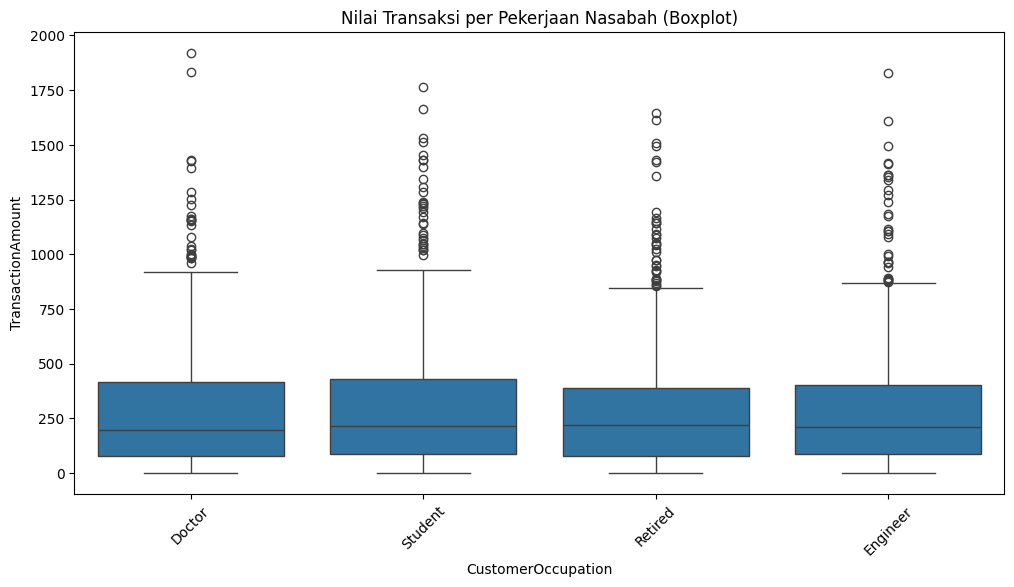

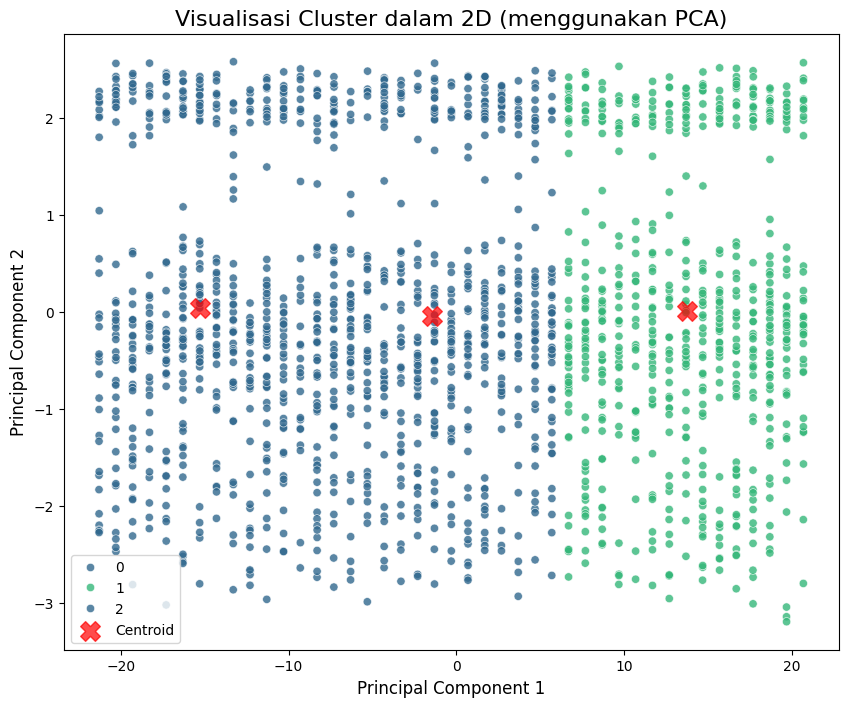

   TransactionAmount  TransactionType  Location  Channel  CustomerAge  \
0          -1.111922                1        36        0     1.426636   
1           0.546926                1        15        0     1.313889   
2          -0.597984                1        23        2    -1.448403   
3          -0.331350                1        33        2    -1.053790   
5          -0.754364                1        28        0    -1.504776   

   CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance  \
0                   0            -0.541568            0.0        0.002918   
1                   0             0.308502            0.0        2.216531   
2                   3            -0.895763            0.0       -1.018513   
3                   3            -1.334965            0.0        0.887895   
5                   3             0.747704            0.0       -1.105726   

   TransactionAmount_bin  Target  
0                      0       1  
1                      2    

In [1]:

# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
# from yellowbrick.cluster import KElbowVisualizer
import joblib

# Load data
df = pd.read_csv("bank_transactions_data_edited.csv")

# Tampilkan 5 baris pertama dengan function head.
# print(df.head())
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
# print(df.info())
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
# print(df.describe())

# Menampilkan korelasi antar fitur (Opsional Skilled 1)

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

# Hitung Matrik Korelasi
correlation = df[numerical_cols].corr()

# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
# plt.show()

# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(
        data=df[[column]], bins=20, kde=True, color='skyblue', ax=axes[i]
        )

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
# plt.show()


# Visualisasi yang lebih informatif (Opsional Advanced 1)
plt.figure(figsize=(12, 6))

# Buat visualisasi boxplot untuk melihat sebaran 'TransactionAmount' (y) berdasarkan 'CustomerOccupation' (x)
sns.boxplot(x="CustomerOccupation", y="TransactionAmount", data=df)
plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")
plt.xticks(rotation=45)
# plt.show()

# Mengecek dataset menggunakan isnull().sum()
print(df.isnull().sum())

# Menangani data yang hilang.
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
print(df.isnull().sum())

# Mengecek dataset menggunakan duplicated().sum()
print(df.duplicated().sum())

# # Menghapus data duplikat.
df.drop_duplicates(inplace=True)

# # Cek kembali dataset menggunakan duplicated().sum()
print(df.duplicated().sum())

# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address
cols_to_drop = [col for col in df.columns if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]

# Gunakan fungsi .drop() untuk menghapus kolom-kolom yang ada di 'cols_to_drop'.
df = df.drop(columns=cols_to_drop)

# Tampilkan 5 baris pertama untuk memverifikasi
print(df.head())


# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.

# Pilih semua kolom yang bertipe 'object' (kategorikal)
categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

# Loop melalui setiap kolom kategorikal
for column in categorical_cols:
    # Buat (instantiate) objek LabelEncoder
    label_encoder = LabelEncoder()

    # Terapkan (fit) encoder ke data dan sekaligus ubah (transform) data tersebut
    df[column] = pd.Series(label_encoder.fit_transform(df[column]), index=df.index)

    # Simpan encoder
    encoders[column] = label_encoder

# Tampilkan 5 baris pertama untuk memverifikasi hasil encoding
print(df.head())

# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
print(df.columns.tolist())

# Melakukan Handling Outlier Data menggunakan metode drop.
for col in numerical_cols:

    # Hitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Hitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Tentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada DI ANTARA (inklusif) batas bawah dan batas atas.
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Tampilkan statistik deskriptif setelah outlier dihapus
print(df.describe())

# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
# Buat (instantiate) StandardScaler
scaler = StandardScaler()

# Terapkan (fit) scaler ke data dan sekaligus ubah (transform) data tersebut
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasil scaling
print(df.head())

# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# Tentukan nama untuk kolom kategori baru
col_to_bin = numerical_cols[0]
new_col_name = f'{col_to_bin}_bin'

# Tentukan label untuk 3 grup (Anda dapat menentukan nama label-nya sendiri)
# Mulai dari rendah --> sedang --> tinggi
bin_labels = ['bin1', 'bin2', 'bin3']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Lakukan Label Encoding pada kolom baru ini agar menjadi numerik
label_encoder = LabelEncoder()
df[new_col_name] = pd.Series(label_encoder.fit_transform(df[new_col_name]), index=df.index)

# Simpan encoder dan tambahkan nama kolom baru ke 'categorical_cols'
encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

# Tampilkan 5 baris pertama untuk memverifikasi
print(df.head())

# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Buat salinan (copy) dari 'df' ke variabel 'df_used'
df_used = df.copy()

# Tampilkan ringkasan statistik dari DataFrame 'df'
print(df_used.head())

# Buat (instantiate) model clustering
model = KMeans()

# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
# Menggunakan algoritma K-Means Clustering
# visualizer = KElbowVisualizer(df_used,
#                        k=list(range(1,11)),
#                        metric=silhouette_score,
#                        timings=False)

# Jalankan (fit) visualizer pada data
# visualizer.fit(df)

# Tampilkan plot
# visualizer.show()

# Menggunakan algoritma K-Means Clustering
model = KMeans(n_clusters=3, random_state=42)

# Latih (fit) model dengan data Anda (df)
model.fit(df)

# Menyimpan model menggunakan joblib
joblib.dump(df_used, 'model')


# Dapatkan hasil (label) cluster dari model 'kmeans' yang telah di-fit
labels = model.fit_predict(df)

# Panggil fungsi untuk menghitung silhouette score
score = silhouette_score(df, labels)

# Menghitung dan menampilkan nilai Silhouette Score.
print("Silhouette Score:", score)

# Membuat visualisasi hasil clustering
# Buat (instantiate) objek PCA untuk 2 komponen (n_components=2)
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df' dan transformasikan data tersebut
df_pca = pca.fit_transform(df)

# Buat DataFrame baru 'df_pca' dari hasil transformasi
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Tambahkan kolom 'Cluster' ke 'df_pca' menggunakan 'labels'(variabel dari hasil 'kmeans.labels_' sebelumnya)
df_pca['Cluster'] = labels

# Buat scatter plot menggunakan Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',  # Warnai titik berdasarkan kolom 'Cluster'
    palette=sns.color_palette("viridis", n_colors=2),
    data=df_pca,
    legend="full",
    alpha=0.8
)

plt.title('Visualisasi Cluster dalam 2D (menggunakan PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()
plt.show()

# Membangun model menggunakan PCA.
# Buat (instantiate) objek PCA dengan 2 komponen
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df_used' dan transformasikan data tersebut
df_pca_array = pca.fit_transform(df_used)

# Buat DataFrame baru 'data_final' dari hasil array PCA
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

# Buat (instantiate) model KMeans BARU
kmeans_pca = KMeans(n_clusters=3, random_state=42)

# Latih (fit) model KMeans BARU ini HANYA pada 'data_final'
kmeans_pca.fit(data_final)

# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Tambahkan kolom 'Cluster' baru berupa 'labels' (variabel dari 'kmeans.labels_' sebelumnya)
df_used['Cluster'] = labels

# Kelompokkan (groupby) 'df_used' berdasarkan 'Cluster' dan hitung agregasi untuk 'numerical_cols'.
agg_summary = df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T # type: ignore

# Tampilkan hasil ringkasan
# print(display(agg_summary))
# Pastikan nama kolom clustering sudah diubah menjadi Target

df_used.rename(columns={"Cluster": "Target"}, inplace=True)

# Tampilkan 5 baris pertama untuk memverifikasi
print(df_used.head())

# Simpan Data
df_used.to_csv('data_clustering.csv', index=False)

# inverse dataset ke rentang normal untuk numerikal
df_inverse = df_used.copy()

# Gunakan 'scaler' untuk mengembalikan 'numerical_cols' ke nilai aslinya.
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
print(df_inverse.head())

# inverse dataset yang sudah diencode ke kategori aslinya.
for column in categorical_cols:
    # Ambil encoder yang tepat untuk 'column' dari dictionary 'encoders'
    encoder = encoders[column]

    # Gunakan scaler untuk mengembalikan (inverse) kolom tersebut
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
print(df_inverse.head())


# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'numerical_cols'.
agg_summary_num = df_inverse.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'categorical_cols'.T
agg_summary_cat = df_inverse.groupby('Target')[categorical_cols].agg(lambda x: x.mode()[0]).round(2).T

# Periksa kembali data yang telah di-inverse.
# print(display(agg_summary_num))
# print(display(agg_summary_cat))
print(df_inverse.head())


# Simpan Data Inverse
df_inverse.to_csv('data_clustering_inverse.csv', index=False)
